In [2]:
import warnings
warnings.filterwarnings("ignore")

## Imports

In [3]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

## Diretório

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base Blend4

In [5]:
df_raw_dev = pd.read_csv(ANALYTICS_DIR/"df_raw_blend4_dev.csv").drop(columns=["Unnamed: 0"])
df_raw_dev["safra"] = df_raw_dev["requested_at"].astype(str).str[:7]
df_raw_dev = df_raw_dev[df_raw_dev["safra"] <= "2025-08"]
df_raw_dev

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356567,3076092,2025-08-31,2025-08-01,260.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,22.0,1.0,6.0,787.5,8836.5,NaN,NaN,0.0,0.0,2025-08
1356568,3076098,2025-08-31,2025-08-01,346.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,42.0,1.0,1.0,945.0,1233.0,NaN,NaN,0.0,0.0,2025-08
1356569,3076101,2025-08-31,2025-08-01,207.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,24.0,1.0,1.0,651.0,1507.0,NaN,NaN,0.0,0.0,2025-08
1356570,3076108,2025-08-31,2025-08-01,392.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,21.0,1.0,0.0,1627.5,5206.0,NaN,0.110814,0.0,0.0,2025-08


## Base Funil

In [6]:
project_id = 'loft-dl-fintech'

query = '''
SELECT 
rf.contract_id,
date(rf.dt_lead) as dt_lead,
date(cf.requested_at) as requested_at,
date(rf.dt_proposta_iniciada) as iniciada_at,
date(rf.dt_proposta_enviada) as enviada_at,
date(rf.activated_at) as activated_at,
date(rf.cancelled_at) as cancelled_at,
date(rf.dt_saida) as dt_saida,
cf.tipo_contrato,
rd.product_nm,
cf.modeloBlend,
cf.bureau_nm,
cf.modelo_blend,
case when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        when cf.bureau_nm in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        when cf.modeloBlend in ('BLEND3_3', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        when cf.bureau_nm in ('BLEND3_3', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        else modeloBlend end as bureau_nm_ajust,
case when cf.modeloBlend in ('BVS_CUSTOM_V2', 'HFT1', 'BVS_CUSTOM', 'HVA4') then 1
        when cf.bureau_nm in ('BVS_CUSTOM_V2', 'HFT1', 'BVS_CUSTOM', 'HVA4') then 1 else 0 end as is_fallback,
cast(rf.total_rental_value_informed_nr as FLOAT64) as total_rental_value_informed_nr,
cast(rf.rental_value_nr as FLOAT64) as rental_value_nr,
cf.qtd_proponentes,
cf.score_imobiliaria,
cf.person_restriction_total_value,
ca.bvs_cust_score_nr,
ca.blend_regressao_predict_nr,
cf.rating_score_ds,
rd.pre_analysis_result,
rd.lead_elegivel,
rd.proposta_iniciada,
rd.proposta_enviada,
rd.proposta_aprovada,
rd.proposta_ativada,
rd.is_activeted
FROM loft-dl-fintech.cp_gold.requests_fact AS rf
LEFT JOIN loft-dl-fintech.cp_gold.requests_dim AS rd
ON rf.contract_id = rd.contract_id
LEFT JOIN loft-dl-fintech.cp_gold.credit_fact AS cf
ON rf.contract_id = cf.contract_id
LEFT JOIN loft-dl-fintech.cp_silver.int_credit_analyses AS ca
ON rf.contract_id = ca.contract_id
WHERE cf.tipo_contrato = 'PF'
and date(cf.requested_at) >= date('2025-01-01')
and date(cf.requested_at) < date(current_date())
'''

In [7]:
# df_funil = pandas_gbq.read_gbq(query, project_id=project_id)
# df_funil

## Consulta Realizada

In [8]:
query_credpago_funil = f"""
WITH funil AS (
  SELECT
    rf.contract_id,
    DATE(rf.dt_lead) AS dt_lead,
    DATE(cf.requested_at) AS requested_at,
    DATE(rf.dt_proposta_iniciada) AS iniciada_at,
    DATE(rf.dt_proposta_enviada) AS enviada_at,
    DATE(rf.activated_at) AS activated_at,
    DATE(rf.cancelled_at) AS cancelled_at,
    DATE(rf.dt_saida) AS dt_saida,
    cf.tipo_contrato,
    rd.product_nm,
    cf.modeloBlend,
    cf.bureau_nm,
    cf.modelo_blend,
    CASE
      WHEN cf.modeloBlend IN ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') THEN 'BLEND4'
      WHEN cf.bureau_nm IN ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') THEN 'BLEND4'
      WHEN cf.modeloBlend IN ('BLEND3_3', 'BVS_CUSTOM', 'HVA4') THEN 'BLEND3'
      WHEN cf.bureau_nm IN ('BLEND3_3', 'BVS_CUSTOM', 'HVA4') THEN 'BLEND3'
      ELSE cf.modeloBlend
    END AS bureau_nm_ajust,
    CASE
      WHEN cf.modeloBlend IN ('BVS_CUSTOM_V2', 'HFT1', 'BVS_CUSTOM', 'HVA4') THEN 1
      WHEN cf.bureau_nm IN ('BVS_CUSTOM_V2', 'HFT1', 'BVS_CUSTOM', 'HVA4') THEN 1
      ELSE 0
    END AS is_fallback,
    CAST(rf.total_rental_value_informed_nr AS FLOAT64) AS total_rental_value_informed_nr,
    CAST(rf.rental_value_nr AS FLOAT64) AS rental_value_nr,
    cf.qtd_proponentes,
    cf.score_imobiliaria,
    cf.person_restriction_total_value,
    ca.bvs_cust_score_nr,
    ca.blend_regressao_predict_nr,
    cf.rating_score_ds,
    rd.pre_analysis_result,
    rd.lead_elegivel,
    rd.proposta_iniciada,
    rd.proposta_enviada,
    rd.proposta_aprovada,
    rd.proposta_ativada,
    rd.is_activeted
  FROM `loft-dl-fintech.cp_gold.requests_fact` AS rf
  LEFT JOIN `loft-dl-fintech.cp_gold.requests_dim` AS rd
    ON rf.contract_id = rd.contract_id
  LEFT JOIN `loft-dl-fintech.cp_gold.credit_fact` AS cf
    ON rf.contract_id = cf.contract_id
  LEFT JOIN `loft-dl-fintech.cp_silver.int_credit_analyses` AS ca
    ON rf.contract_id = ca.contract_id
  WHERE cf.tipo_contrato = 'PF'
    AND DATE(cf.requested_at) >= DATE('2025-01-01')
    AND DATE(cf.requested_at) < CURRENT_DATE()
),

consulta_realizada AS (
  SELECT
    CAST(REGEXP_REPLACE(CR.documento, r'[^0-9]', '') AS INT64) AS CPF_CNPJ,
    SAFE_CAST(CR.id_externo AS INT64) AS contract_id,
    DATE(CR.data) AS data_consulta,
    CR.model,
    -- first proponent (index 0), with/without message wrapper
    CAST(COALESCE(
      JSON_VALUE(CR.json_retornado, '$.pessoas[0].scores.BVS_CUSTOM'),
      JSON_VALUE(CR.json_retornado, '$.message.pessoas[0].scores.BVS_CUSTOM')
    ) AS FLOAT64) AS pessoas_scores_BVS_CUSTOM,
    CAST(COALESCE(
      JSON_VALUE(CR.json_retornado, '$.pessoas[0].scores.BVS_CUSTOM_V2'),
      JSON_VALUE(CR.json_retornado, '$.message.pessoas[0].scores.BVS_CUSTOM_V2')
    ) AS FLOAT64) AS pessoas_scores_BVS_CUSTOM_V2,
    CAST(COALESCE(
      JSON_VALUE(CR.json_retornado, '$.pessoas[0].scores.HVA4'),
      JSON_VALUE(CR.json_retornado, '$.message.pessoas[0].scores.HVA4')
    ) AS FLOAT64) AS pessoas_scores_HVA4,
    CAST(COALESCE(
      JSON_VALUE(CR.json_retornado, '$.pessoas[0].scores.HFT1'),
      JSON_VALUE(CR.json_retornado, '$.message.pessoas[0].scores.HFT1')
    ) AS FLOAT64) AS pessoas_scores_HFT1,
    CAST(COALESCE(
      JSON_VALUE(CR.json_retornado, '$.pessoas[0].rendaConsideradaPessoa'),
      JSON_VALUE(CR.json_retornado, '$.message.pessoas[0].rendaConsideradaPessoa')
    ) AS FLOAT64) AS pessoas_rendaConsideradaPessoa
  FROM `loft-dl-fintech.bronze_credpago_sortinghat.consulta_realizada` AS CR
  INNER JOIN funil AS f
    ON SAFE_CAST(CR.id_externo AS INT64) = f.contract_id
  WHERE DATE(CR.data) >= DATE('2025-01-01')
    AND DATE(CR.data) < CURRENT_DATE()
),

credpago_1row AS (
  SELECT *
  FROM consulta_realizada
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY contract_id
    ORDER BY
      CASE WHEN model = 'BLEND_4' THEN 1 ELSE 2 END ASC,  -- optional; same as renda notebook
      data_consulta DESC
  ) = 1
)

SELECT
  f.*,
  c.CPF_CNPJ,
  c.data_consulta,
  c.model,
  c.pessoas_scores_BVS_CUSTOM,
  c.pessoas_scores_BVS_CUSTOM_V2,
  c.pessoas_scores_HVA4,
  c.pessoas_scores_HFT1,
  c.pessoas_rendaConsideradaPessoa
FROM funil AS f
INNER JOIN credpago_1row AS c   -- use LEFT JOIN if you want funnel rows without CR
  ON f.contract_id = c.contract_id
"""

In [9]:
# query_credpago_funil_df = pd.read_gbq(query_credpago_funil, project_id=project_id)
# query_credpago_funil_df

In [10]:
# query_credpago_funil_df.to_parquet(ANALYTICS_DIR/"query_credpago_funil_df.parquet")

In [11]:
cp_funil_df = pd.read_parquet(ANALYTICS_DIR/"query_credpago_funil_df.parquet")
cp_funil_df

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,proposta_ativada,is_activeted,CPF_CNPJ,data_consulta,model,pessoas_scores_BVS_CUSTOM,pessoas_scores_BVS_CUSTOM_V2,pessoas_scores_HVA4,pessoas_scores_HFT1,pessoas_rendaConsideradaPessoa
0,3478800,2025-12-02,2025-12-02,2025-12-02,2025-12-02,2025-12-02,NaT,NaT,PF,Smart Plus,...,True,True,9255574981,2025-12-02,BLEND_REGRESSAO,682.0,NaN,NaN,NaN,2329.0
1,3479884,2025-12-02,2025-12-02,2025-12-11,2025-12-11,NaT,NaT,NaT,PF,Fit,...,False,False,58132171934,2025-12-11,BLEND_REGRESSAO,629.0,NaN,NaN,NaN,2534.5
2,3481527,2025-12-02,2025-12-02,NaT,NaT,NaT,NaT,NaT,PF,None,...,False,False,3068059283,2025-12-04,BLEND_REGRESSAO,776.0,NaN,NaN,NaN,4452.5
3,3480573,2025-12-02,2025-12-02,2025-12-02,2025-12-02,NaT,NaT,NaT,PF,Fit,...,False,False,42068193949,2025-12-04,BLEND_REGRESSAO,667.0,NaN,NaN,NaN,1986.5
4,3481572,2025-12-02,2025-12-02,NaT,NaT,NaT,2025-12-02,NaT,PF,None,...,False,False,71626328072,2025-12-02,BVS_CUSTOM,435.0,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200990,2684055,2025-06-05,2025-06-05,2025-06-05,2025-06-05,2025-06-06,2026-03-05,2026-03-03,PF,Fit,...,True,True,50175485801,2025-06-05,BLEND_REGRESSAO,656.0,NaN,NaN,NaN,1438.5
2200991,2683769,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,False,False,2576327001,2025-06-05,BLEND_REGRESSAO,421.0,NaN,NaN,NaN,2671.5
2200992,2684433,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,False,False,11706303670,2025-06-05,BLEND_REGRESSAO,701.0,NaN,NaN,NaN,1644.0
2200993,2686312,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,False,False,87168995987,2025-06-05,BLEND_REGRESSAO_OTIMISTA,435.0,NaN,NaN,NaN,4315.5


## Aluguel Histórico

In [12]:
project_id = 'loft-dl-fintech'

query = '''
SELECT
id_imovel AS contract_id,
CAST(vl_aluguel AS FLOAT64) AS rental_value,
DATE(data) AS requested_at
FROM `loft-dl-fintech.bronze_credpago_snapshot.historico_valor`
QUALIFY ROW_NUMBER() OVER (PARTITION BY id_imovel ORDER BY data DESC) = 1
'''

df_rental_value = pd.read_gbq(query, project_id=project_id)

In [13]:
df_rental_value = df_rental_value.drop(columns=["requested_at"])
df_rental_value = df_rental_value.rename(columns={"rental_value": "rental_value_base"})

## Join

In [14]:
df_raw = df_raw_dev.merge(df_rental_value, on="contract_id", how="left")
df_raw

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra,rental_value_base
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09,2200.0
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09,1850.0
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09,1900.0
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09,1900.0
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09,2600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070231,3076092,2025-08-31,2025-08-01,260.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,1.0,6.0,787.5,8836.5,NaN,NaN,0.0,0.0,2025-08,750.0
1070232,3076098,2025-08-31,2025-08-01,346.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,1.0,1.0,945.0,1233.0,NaN,NaN,0.0,0.0,2025-08,900.0
1070233,3076101,2025-08-31,2025-08-01,207.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,1.0,1.0,651.0,1507.0,NaN,NaN,0.0,0.0,2025-08,620.0
1070234,3076108,2025-08-31,2025-08-01,392.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,1.0,0.0,1627.5,5206.0,NaN,0.110814,0.0,0.0,2025-08,1550.0


In [15]:
cp_funil_df_join = cp_funil_df.merge(df_rental_value, on="contract_id", how="left")
cp_funil_df_join["rental_value"] = cp_funil_df_join["rental_value_base"]
cp_funil_df_join

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,CPF_CNPJ,data_consulta,model,pessoas_scores_BVS_CUSTOM,pessoas_scores_BVS_CUSTOM_V2,pessoas_scores_HVA4,pessoas_scores_HFT1,pessoas_rendaConsideradaPessoa,rental_value_base,rental_value
0,3478800,2025-12-02,2025-12-02,2025-12-02,2025-12-02,2025-12-02,NaT,NaT,PF,Smart Plus,...,9255574981,2025-12-02,BLEND_REGRESSAO,682.0,NaN,NaN,NaN,2329.0,1166.67,1166.67
1,3479884,2025-12-02,2025-12-02,2025-12-11,2025-12-11,NaT,NaT,NaT,PF,Fit,...,58132171934,2025-12-11,BLEND_REGRESSAO,629.0,NaN,NaN,NaN,2534.5,2900.00,2900.00
2,3481527,2025-12-02,2025-12-02,NaT,NaT,NaT,NaT,NaT,PF,None,...,3068059283,2025-12-04,BLEND_REGRESSAO,776.0,NaN,NaN,NaN,4452.5,1641.00,1641.00
3,3480573,2025-12-02,2025-12-02,2025-12-02,2025-12-02,NaT,NaT,NaT,PF,Fit,...,42068193949,2025-12-04,BLEND_REGRESSAO,667.0,NaN,NaN,NaN,1986.5,1770.00,1770.00
4,3481572,2025-12-02,2025-12-02,NaT,NaT,NaT,2025-12-02,NaT,PF,None,...,71626328072,2025-12-02,BVS_CUSTOM,435.0,NaN,NaN,NaN,0.0,4400.00,4400.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200990,2684055,2025-06-05,2025-06-05,2025-06-05,2025-06-05,2025-06-06,2026-03-05,2026-03-03,PF,Fit,...,50175485801,2025-06-05,BLEND_REGRESSAO,656.0,NaN,NaN,NaN,1438.5,1200.00,1200.00
2200991,2683769,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,2576327001,2025-06-05,BLEND_REGRESSAO,421.0,NaN,NaN,NaN,2671.5,1650.00,1650.00
2200992,2684433,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,11706303670,2025-06-05,BLEND_REGRESSAO,701.0,NaN,NaN,NaN,1644.0,1100.00,1100.00
2200993,2686312,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,87168995987,2025-06-05,BLEND_REGRESSAO_OTIMISTA,435.0,NaN,NaN,NaN,4315.5,1100.00,1100.00


In [16]:
cp_funil_df_join = cp_funil_df_join[cp_funil_df_join["rental_value_base"] > 0]
cp_funil_df_join["safra"] = cp_funil_df_join["requested_at"].astype(str).str[:7]
cp_funil_df_join["activated"] = cp_funil_df_join["activated_at"].notna().astype(int)
cp_funil_df_join

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,model,pessoas_scores_BVS_CUSTOM,pessoas_scores_BVS_CUSTOM_V2,pessoas_scores_HVA4,pessoas_scores_HFT1,pessoas_rendaConsideradaPessoa,rental_value_base,rental_value,safra,activated
0,3478800,2025-12-02,2025-12-02,2025-12-02,2025-12-02,2025-12-02,NaT,NaT,PF,Smart Plus,...,BLEND_REGRESSAO,682.0,NaN,NaN,NaN,2329.0,1166.67,1166.67,2025-12,1
1,3479884,2025-12-02,2025-12-02,2025-12-11,2025-12-11,NaT,NaT,NaT,PF,Fit,...,BLEND_REGRESSAO,629.0,NaN,NaN,NaN,2534.5,2900.00,2900.00,2025-12,0
2,3481527,2025-12-02,2025-12-02,NaT,NaT,NaT,NaT,NaT,PF,None,...,BLEND_REGRESSAO,776.0,NaN,NaN,NaN,4452.5,1641.00,1641.00,2025-12,0
3,3480573,2025-12-02,2025-12-02,2025-12-02,2025-12-02,NaT,NaT,NaT,PF,Fit,...,BLEND_REGRESSAO,667.0,NaN,NaN,NaN,1986.5,1770.00,1770.00,2025-12,0
4,3481572,2025-12-02,2025-12-02,NaT,NaT,NaT,2025-12-02,NaT,PF,None,...,BVS_CUSTOM,435.0,NaN,NaN,NaN,0.0,4400.00,4400.00,2025-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200990,2684055,2025-06-05,2025-06-05,2025-06-05,2025-06-05,2025-06-06,2026-03-05,2026-03-03,PF,Fit,...,BLEND_REGRESSAO,656.0,NaN,NaN,NaN,1438.5,1200.00,1200.00,2025-06,1
2200991,2683769,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,BLEND_REGRESSAO,421.0,NaN,NaN,NaN,2671.5,1650.00,1650.00,2025-06,0
2200992,2684433,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,BLEND_REGRESSAO,701.0,NaN,NaN,NaN,1644.0,1100.00,1100.00,2025-06,0
2200993,2686312,2025-06-05,2025-06-05,NaT,NaT,NaT,2025-06-05,NaT,PF,None,...,BLEND_REGRESSAO_OTIMISTA,435.0,NaN,NaN,NaN,4315.5,1100.00,1100.00,2025-06,0


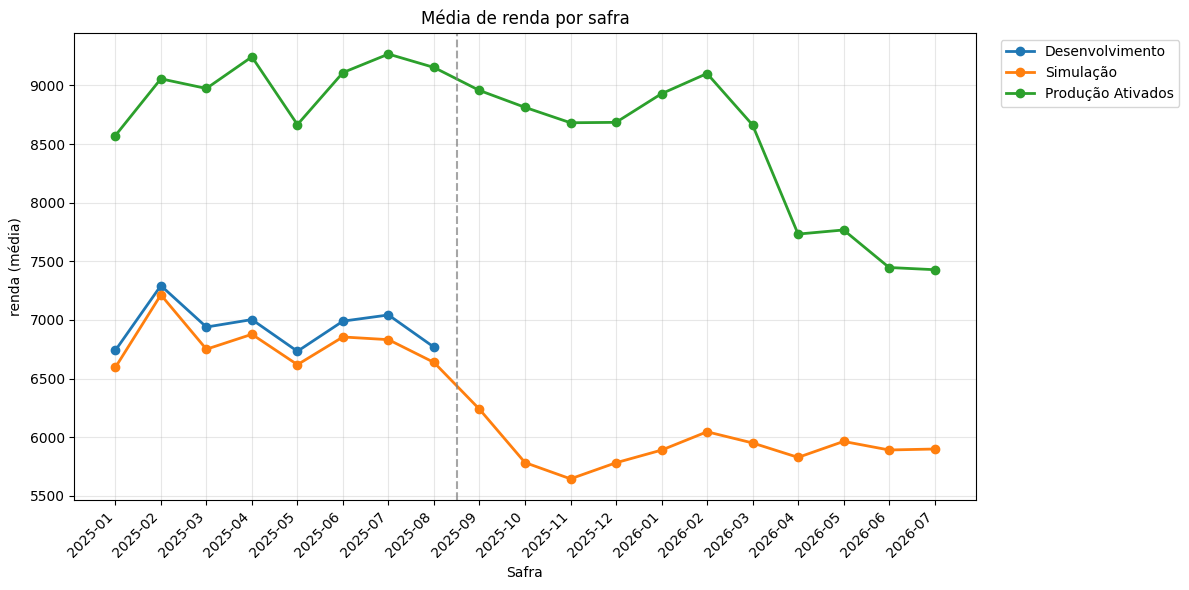

In [17]:
var_dev = "income"
var_prod = "pessoas_rendaConsideradaPessoa"

s1 = (
    df_raw[df_raw["safra"] >= "2025-01"]
    .assign(**{var_dev: lambda d: pd.to_numeric(d[var_dev], errors="coerce")})
    .groupby("safra", as_index=False)[var_dev]
    .agg(mean="mean")
)

s2 = (
    cp_funil_df_join
    .assign(**{var_prod: lambda d: pd.to_numeric(d[var_prod], errors="coerce")})
    .groupby("safra", as_index=False)[var_prod]
    .agg(mean="mean")
)

s3 = (
    cp_funil_df_join[cp_funil_df_join["activated"] == 1]
    .assign(**{var_prod: lambda d: pd.to_numeric(d[var_prod], errors="coerce")})
    .groupby("safra", as_index=False)[var_prod]
    .agg(mean="mean")
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}
s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)
s3["x"] = s3["safra"].map(x_map)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(s1["x"], s1["mean"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["mean"], marker="o", linewidth=2, label="Simulação")
ax.plot(s3["x"], s3["mean"], marker="o", linewidth=2, label="Produção Ativados")

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("renda (média)")
ax.set_title("Média de renda por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Em Outubro/25, a Melanie testou uma nova renda da SERASA. Renda anterior teria sido descontinuada e essa nova renda entrou em vigor.

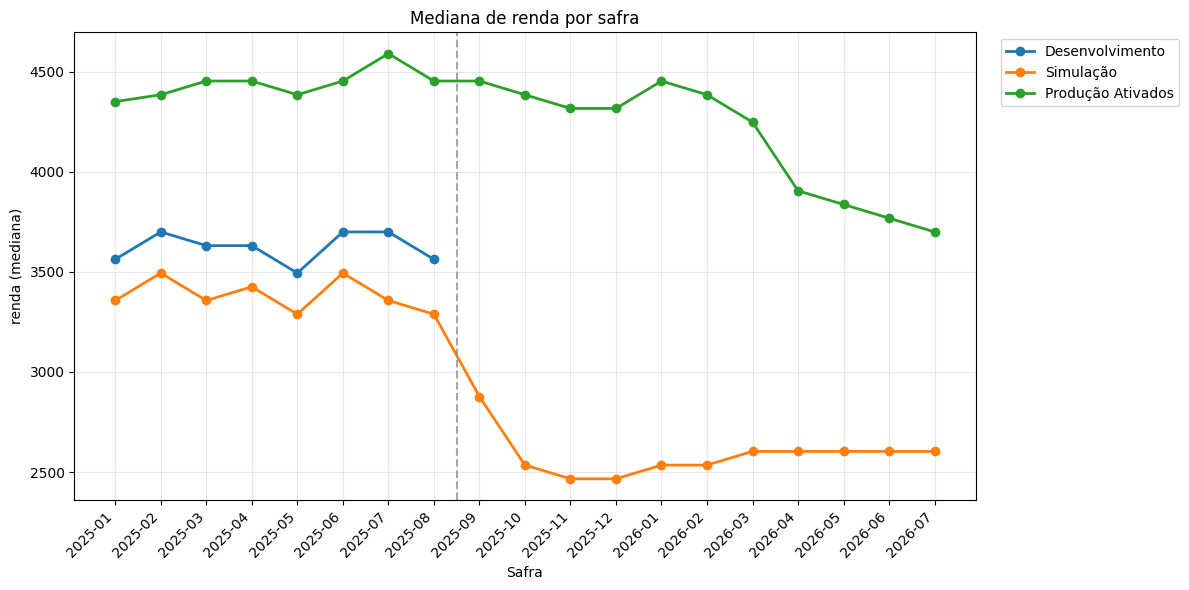

In [18]:
var_dev = "income"
var_prod = "pessoas_rendaConsideradaPessoa"

s1 = (
    df_raw[df_raw["safra"] >= "2025-01"]
    .assign(**{var_dev: lambda d: pd.to_numeric(d[var_dev], errors="coerce")})
    .groupby("safra", as_index=False)[var_dev]
    .agg(p50=lambda s: s.quantile(0.50))
)

s2 = (
    cp_funil_df_join
    .assign(**{var_prod: lambda d: pd.to_numeric(d[var_prod], errors="coerce")})
    .groupby("safra", as_index=False)[var_prod]
    .agg(p50=lambda s: s.quantile(0.50))
)

s3 = (
    cp_funil_df_join[cp_funil_df_join["activated"] == 1]
    .assign(**{var_prod: lambda d: pd.to_numeric(d[var_prod], errors="coerce")})
    .groupby("safra", as_index=False)[var_prod]
    .agg(p50=lambda s: s.quantile(0.50))
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}
s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)
s3["x"] = s3["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="Simulação")
ax.plot(s3["x"], s3["p50"], marker="o", linewidth=2, label="Produção Ativados")

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("renda (mediana)")
ax.set_title("Mediana de renda por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Aluguel

In [36]:
var = "rental_value_base"
x = pd.to_numeric(cp_funil_df_join[var], errors="coerce")

print(x.describe(percentiles=[0.01, 0.5, 0.9, 0.99, 0.999]))
print("max:", x.max())
print("acima de 50k:", (x > 50_000).sum())
print("acima de 100k:", (x > 100_000).sum())
cp_funil_df_join.loc[x.nlargest(20).index, ["contract_id", "safra", var]]

count    2.200995e+06
mean     3.882948e+08
std      2.679113e+11
min      1.000000e+00
1%       5.500000e+02
50%      1.500000e+03
90%      3.200000e+03
99%      8.000000e+03
99.9%    2.000000e+04
max      2.450072e+14
Name: rental_value_base, dtype: float64
max: 245007181760300.0
acima de 50k: 805
acima de 100k: 676


,contract_id,safra,rental_value_base
956851,4280408,2026-06,2.450072e+14
462424,4098375,2026-05,2.000750e+14
828566,3102209,2025-09,1.600496e+14
515852,2835638,2025-07,1.500119e+14
1362577,3271331,2025-10,9.900413e+13
2006564,2941108,2025-07,1.225384e+11
1771294,2549051,2025-04,1.000000e+11
1630861,2953528,2025-08,7.054599e+10
342573,3621566,2026-01,5.790843e+10
1991203,3624004,2026-01,4.462618e+10


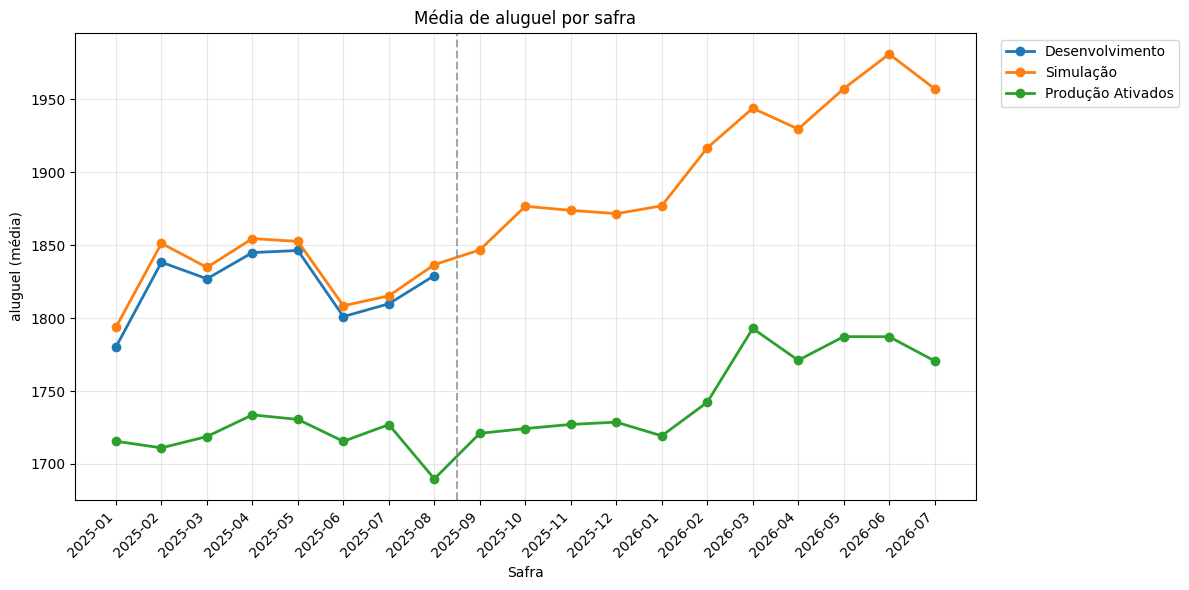

In [39]:
var = "rental_value_base"

# Trim bottom/top 1% of rental_value_base (same limits for s2 and s3)
x = pd.to_numeric(cp_funil_df_join[var], errors="coerce")
lo, hi = x.quantile(0.001), x.quantile(0.999)
cp_plot = cp_funil_df_join[x.between(lo, hi)].copy()

s1 = (
    df_raw[df_raw["safra"] >= "2025-01"]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(mean="mean")
)

s2 = (
    cp_plot
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(mean="mean")
)

s3 = (
    cp_funil_df_join[cp_funil_df_join["activated"] == 1]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(mean="mean")
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}
s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)
s3["x"] = s3["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(s1["x"], s1["mean"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["mean"], marker="o", linewidth=2, label="Simulação")
ax.plot(s3["x"], s3["mean"], marker="o", linewidth=2, label="Produção Ativados")
sep = s1["x"].max() + 0.5
ax.axvline(sep, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("aluguel (média)")
ax.set_title("Média de aluguel por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

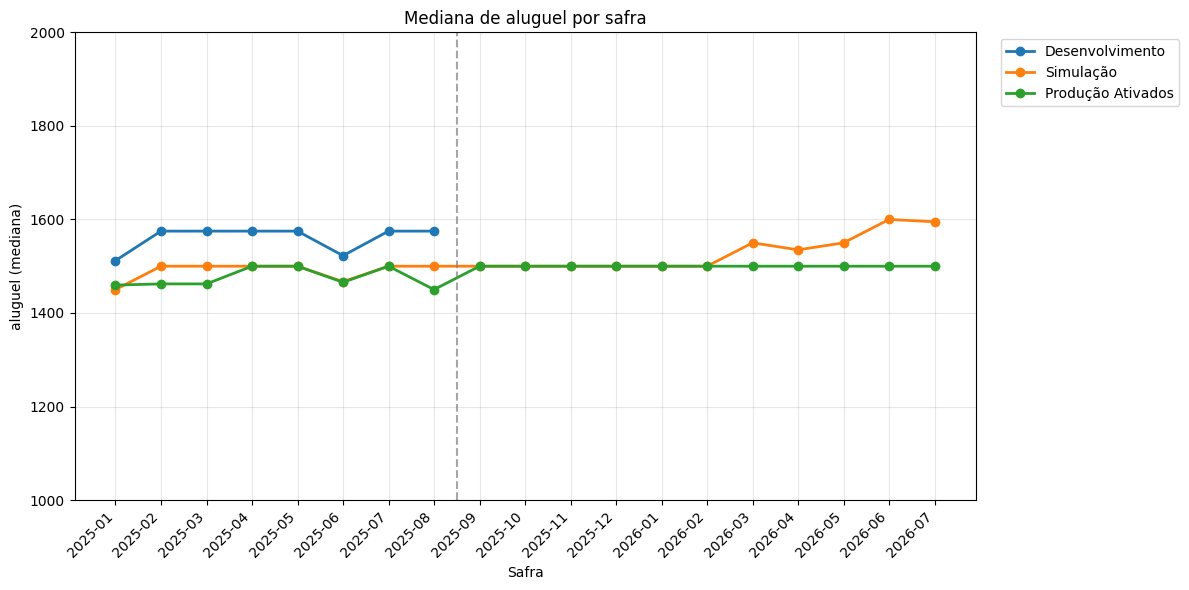

In [ ]:
var = "rental_value"

s1 = (
    df_raw_dev[df_raw_dev["safra"] >= "2025-01"]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

s2 = (
    cp_funil_df_join
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

s3 = (
    cp_funil_df_join[cp_funil_df_join["activated"] == 1]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}
s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)
s3["x"] = s3["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="Simulação")
ax.plot(s3["x"], s3["p50"], marker="o", linewidth=2, label="Produção Ativados")
sep = s1["x"].max() + 0.5
ax.axvline(sep, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("aluguel (mediana)")
ax.set_ylim(1000, 2000)
ax.set_title("Mediana de aluguel por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

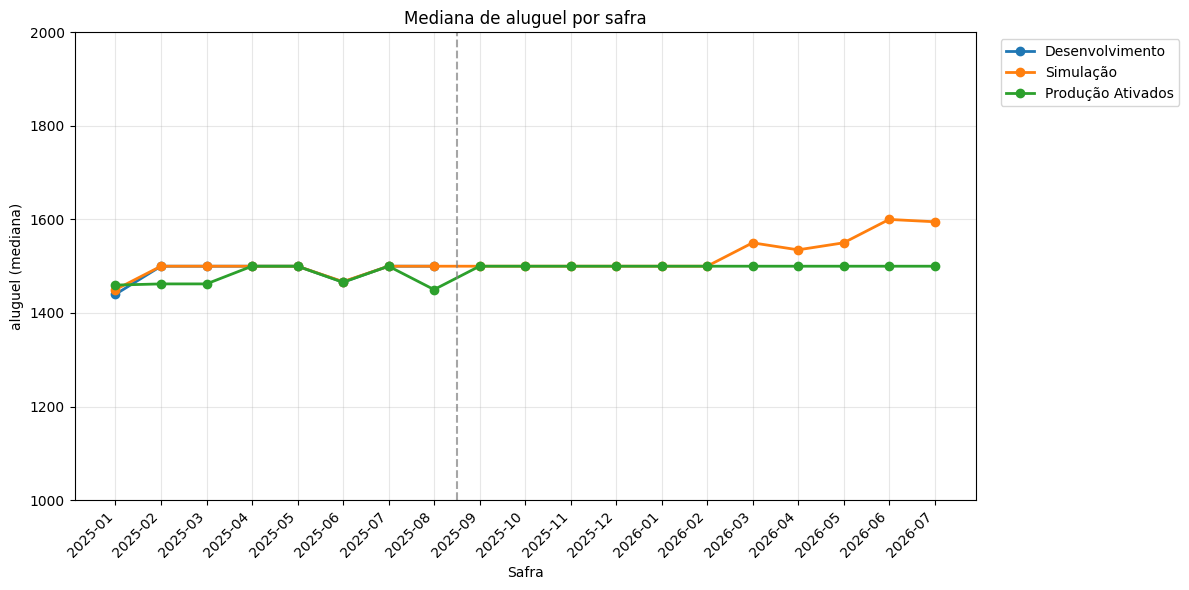

In [22]:
var = "rental_value_base"

s1 = (
    df_raw[df_raw["safra"] >= "2025-01"]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

s2 = (
    cp_funil_df_join
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

s3 = (
    cp_funil_df_join[cp_funil_df_join["activated"] == 1]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}
s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)
s3["x"] = s3["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="Simulação")
ax.plot(s3["x"], s3["p50"], marker="o", linewidth=2, label="Produção Ativados")
sep = s1["x"].max() + 0.5
ax.axvline(sep, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("aluguel (mediana)")
ax.set_ylim(1000, 2000)
ax.set_title("Mediana de aluguel por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Aluguel com corte BVS
BVS SCORE V1 >= 478

In [32]:
cp_funil_df_join.columns

Index(['contract_id', 'dt_lead', 'requested_at', 'iniciada_at', 'enviada_at',
       'activated_at', 'cancelled_at', 'dt_saida', 'tipo_contrato',
       'product_nm', 'modeloBlend', 'bureau_nm', 'modelo_blend',
       'bureau_nm_ajust', 'is_fallback', 'total_rental_value_informed_nr',
       'rental_value_nr', 'qtd_proponentes', 'score_imobiliaria',
       'person_restriction_total_value', 'bvs_cust_score_nr',
       'blend_regressao_predict_nr', 'rating_score_ds', 'pre_analysis_result',
       'lead_elegivel', 'proposta_iniciada', 'proposta_enviada',
       'proposta_aprovada', 'proposta_ativada', 'is_activeted', 'CPF_CNPJ',
       'data_consulta', 'model', 'pessoas_scores_BVS_CUSTOM',
       'pessoas_scores_BVS_CUSTOM_V2', 'pessoas_scores_HVA4',
       'pessoas_scores_HFT1', 'pessoas_rendaConsideradaPessoa',
       'rental_value_base', 'rental_value', 'safra', 'activated'],
      dtype='object')

In [33]:
cp_funil_df_join[cp_funil_df_join["pessoas_scores_BVS_CUSTOM"].isna()].groupby("model").size()

model
                           79
BLEND3_2                  124
BLEND3_3                  646
BLEND3_BVS                  6
BLEND3_POD               1831
BLEND_4                  8538
BLEND_HVA3_BVS          19505
BVS                       486
BVS_CUSTOM               5973
BVS_CUSTOM_OTIMISTA       322
BVS_CUSTOM_V2             147
HFT1                      107
HVA3                   196129
HVA4                     2850
HVAR                    24607
dtype: int64

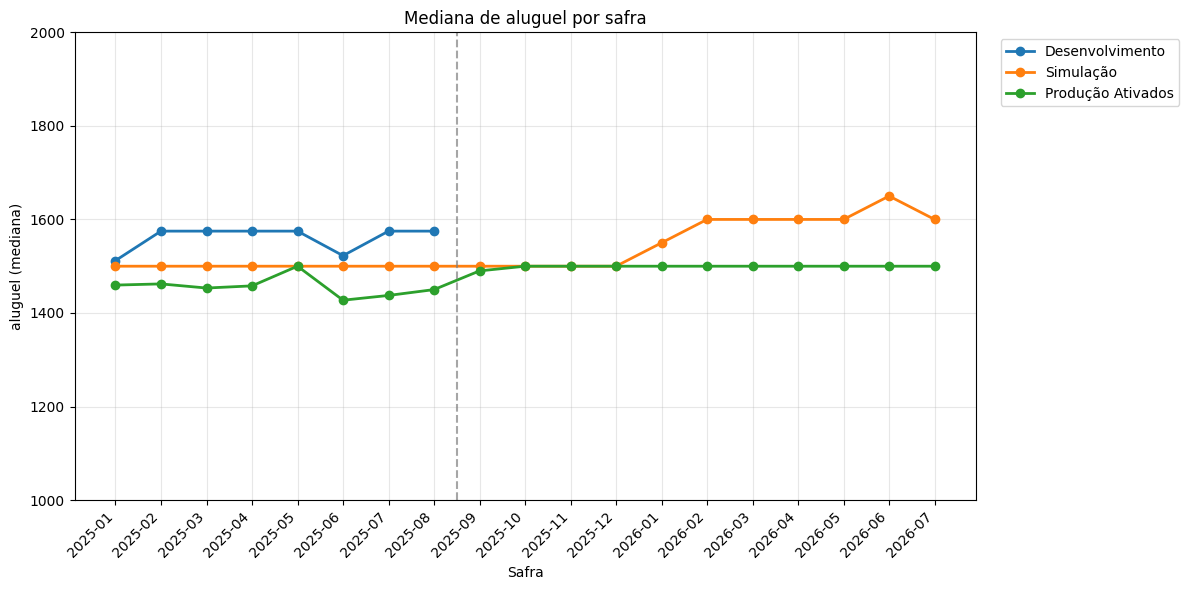

In [34]:
var = "rental_value"

s1 = (
    df_raw_dev[df_raw_dev["safra"] >= "2025-01"]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

s2 = (
    cp_funil_df_join[cp_funil_df_join["pessoas_scores_BVS_CUSTOM"] >= 478]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

s3 = (
    cp_funil_df_join[(cp_funil_df_join["activated"] == 1)
    &(cp_funil_df_join["pessoas_scores_BVS_CUSTOM"].notna())
    &(cp_funil_df_join["pessoas_scores_BVS_CUSTOM"] >= 478)]
    .assign(**{var: lambda d: pd.to_numeric(d[var], errors="coerce")})
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50))
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}
s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)
s3["x"] = s3["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="Simulação")
ax.plot(s3["x"], s3["p50"], marker="o", linewidth=2, label="Produção Ativados")
sep = s1["x"].max() + 0.5
ax.axvline(sep, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("aluguel (mediana)")
ax.set_ylim(1000, 2000)
ax.set_title("Mediana de aluguel por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [23]:
aquii

NameError: name 'aquii' is not defined

Amanhã fazer a parte PC Carteira (13 meses, 7 meses)

## PC Carteira

In [ ]:
project_id = 'loft-dl-fintech'

query_sql = '''
WITH 
first_defaults AS (
  SELECT
    contract_id,
    DATE(MIN(pendency_at)) AS com_comp
  FROM `loft-dl-fintech.cp_gold.watchlist_fact`
  WHERE pendency_type IN ('Inadimplência', 'Inadimplência')
  GROUP BY contract_id
),
leads_e_defaults AS (
  SELECT
    r.contract_id,
    DATE(cf.requested_at) AS requested_at,
    CASE WHEN rd.pre_analysis_result IN ('DERIVAR', 'APROVAR') THEN 1 ELSE 0 END AS lead_elegivel_pre_analysis,
    DATE(r.activated_at) AS activated_at,
    i.id_cidade_ibge,
    fd.com_comp,
    DATE_DIFF(
      DATE_TRUNC(CURRENT_DATE(), MONTH),
      DATE_TRUNC(COALESCE(DATE(r.activated_at), DATE(cf.requested_at)), MONTH),
      MONTH
    ) AS time2requested,
    CASE
      WHEN fd.com_comp IS NULL OR r.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.com_comp), MONTH),
        DATE_TRUNC(DATE(r.activated_at), MONTH),
        MONTH
      )
    END AS time2def
  FROM `loft-dl-fintech.cp_gold.requests_fact` r
  LEFT JOIN `loft-dl-fintech.cp_gold.requests_dim` AS rd
    ON r.contract_id = rd.contract_id
  LEFT JOIN `loft-dl-fintech.cp_gold.credit_fact` AS cf
    ON r.contract_id = cf.contract_id
  LEFT JOIN `loft-dl-fintech.bronze_credpago.imovel` i
    ON r.contract_id = i.id
  LEFT JOIN first_defaults fd
    ON fd.contract_id = r.contract_id
  WHERE 1=1
    AND DATE(cf.requested_at) >= DATE_SUB(DATE('2026-05-01'), INTERVAL 49 MONTH)
    AND DATE(cf.requested_at) <  DATE('2026-05-01')
    AND cf.tipo_contrato = 'PF'
),
leads_e_defaults_mob AS (
  SELECT
    *,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN com_comp IS NOT NULL AND time2requested >= 4 AND time2def <= 4 THEN 1
      WHEN time2requested >= 4 THEN 0
      ELSE NULL
    END AS comunicado_4,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN com_comp IS NOT NULL AND time2requested >= 6 AND time2def <= 6 THEN 1
      WHEN time2requested >= 6 THEN 0
      ELSE NULL
    END AS comunicado_6,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN com_comp IS NOT NULL AND time2requested >= 12 AND time2def <= 12 THEN 1
      WHEN time2requested >= 12 THEN 0
      ELSE NULL
    END AS comunicado_12
  FROM leads_e_defaults
)
SELECT *
FROM leads_e_defaults_mob
WHERE comunicado_4 IS NOT NULL
   OR comunicado_6 IS NOT NULL
   OR comunicado_12 IS NOT NULL
'''

In [ ]:
df_inad = pd.read_gbq(query_sql, project_id=project_id)
df_inad

,contract_id,requested_at,lead_elegivel_pre_analysis,activated_at,id_cidade_ibge,com_comp,time2requested,time2def,comunicado_4,comunicado_6,comunicado_12
0,1993142,2024-10-18,1,2020-10-18,3540754,2024-12-10,69,50,0,0,0
1,3798215,2026-02-23,1,2026-03-03,3106705,None,4,<NA>,0,<NA>,<NA>
2,3814719,2026-02-25,1,2026-03-02,4113700,None,4,<NA>,0,<NA>,<NA>
3,3811189,2026-02-25,1,2026-03-06,5208707,None,4,<NA>,0,<NA>,<NA>
4,3815172,2026-02-25,1,2026-03-04,4113700,None,4,<NA>,0,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
696688,581662,2022-04-08,1,2022-04-12,5300108,2022-07-11,51,3,1,1,1
696689,581844,2022-04-08,1,2022-04-12,5008305,None,51,<NA>,0,0,0
696690,580718,2022-04-08,1,2022-04-08,4125506,None,51,<NA>,0,0,0
696691,581838,2022-04-08,1,2022-04-11,4314902,None,51,<NA>,0,0,0


In [ ]:
df_inad["safra"] = pd.to_datetime(df_inad["requested_at"]).dt.to_period("M").astype(str)

summary = (
    df_inad.groupby("safra", as_index=False)
    .agg(
        n_4=("comunicado_4", "count"),
        pc_4m=("comunicado_4", "mean"),
        n_6=("comunicado_6", "count"),
        pc_6m=("comunicado_6", "mean"),
        n_12=("comunicado_12", "count"),
        pc_12m=("comunicado_12", "mean"),
    )
    .sort_values("safra")
)

In [ ]:
from pandas.tseries.offsets import MonthBegin

df_inad["safra"] = pd.to_datetime(df_inad["requested_at"]).dt.to_period("M").astype(str)
df_inad["safra_dt"] = pd.to_datetime(df_inad["safra"] + "-01")

# reference safras you want to evaluate (e.g. monitoring months)
# ref_safras = pd.period_range("2026-01", "2026-06", freq="M").astype(str)
ref_safras = pd.period_range("2023-05", "2026-06", freq="M").astype(str)

rows = []
for ref in ref_safras:
    ref_dt = pd.to_datetime(ref + "-01")
    start = ref_dt + MonthBegin(-13)  # 2026-06 -> 2025-05
    end = ref_dt + MonthBegin(-7)     # 2026-06 -> 2025-11

    mask = (df_inad["safra_dt"] >= start) & (df_inad["safra_dt"] <= end)
    window = df_inad.loc[mask]

    rows.append({
        "safra_ref": ref,
        "window_start": start.strftime("%Y-%m"),
        "window_end": end.strftime("%Y-%m"),
        "n_4": window["comunicado_4"].count(),
        "pc_4m": window["comunicado_4"].mean(),
        "n_6": window["comunicado_6"].count(),
        "pc_6m": window["comunicado_6"].mean(),
        "n_12": window["comunicado_12"].count(),
        "pc_12m": window["comunicado_12"].mean(),
    })

summary_window = pd.DataFrame(rows)
summary_window

,safra_ref,window_start,window_end,n_4,pc_4m,n_6,pc_6m,n_12,pc_12m
0,2023-05,2022-04,2022-10,78583,0.098138,78583,0.135411,78583,0.222733
1,2023-06,2022-05,2022-11,77911,0.098369,77911,0.135642,77911,0.222420
2,2023-07,2022-06,2022-12,75280,0.097848,75280,0.135268,75280,0.219633
3,2023-08,2022-07,2023-01,78353,0.097724,78353,0.134315,78353,0.217120
4,2023-09,2022-08,2023-02,78694,0.099334,78694,0.135601,78694,0.217590
5,2023-10,2022-09,2023-03,81285,0.099932,81285,0.136187,81285,0.218466
6,2023-11,2022-10,2023-04,82470,0.100582,82470,0.136595,82470,0.219001
7,2023-12,2022-11,2023-05,87301,0.100789,87301,0.137581,87301,0.221383
8,2024-01,2022-12,2023-06,90933,0.100052,90933,0.136848,90933,0.221845
9,2024-02,2023-01,2023-07,94738,0.100139,94738,0.136651,94738,0.223669


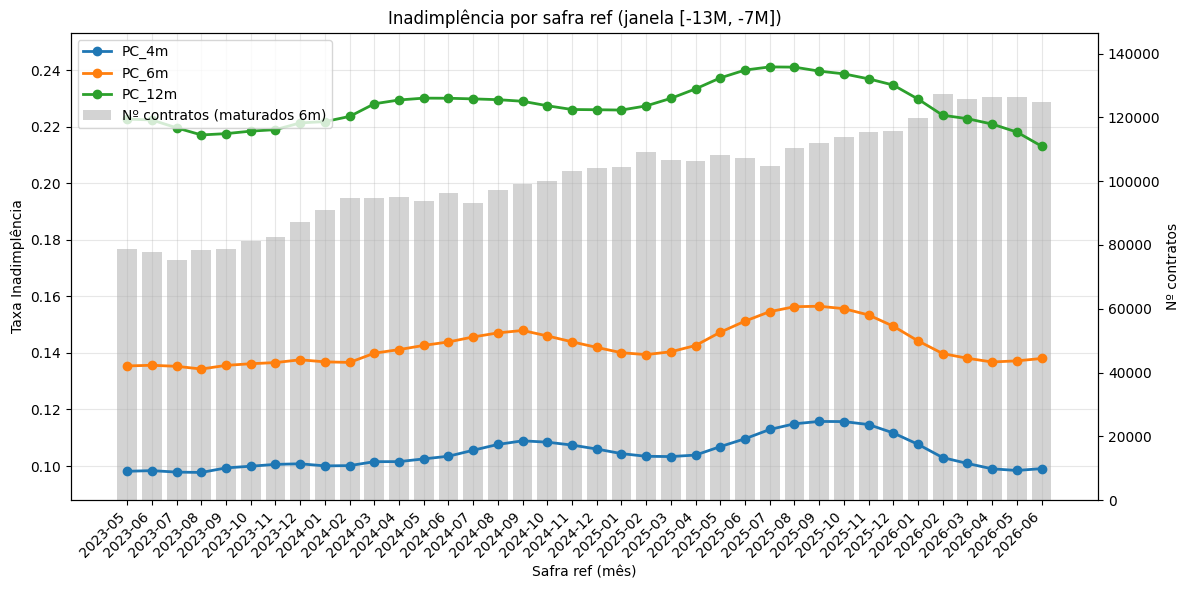

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

# bars in the background
ax2.bar(
    summary_window["safra_ref"],
    summary_window["n_6"],
    color="lightgray",
    width=0.8,
    label="Nº contratos (maturados 6m)",
    zorder=1,
)

# lines in front
ax.plot(summary_window["safra_ref"], summary_window["pc_4m"], marker="o", linewidth=2, label="PC_4m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pc_6m"], marker="o", linewidth=2, label="PC_6m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pc_12m"], marker="o", linewidth=2, label="PC_12m", zorder=3)

ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax.set_xlabel("Safra ref (mês)")
ax.set_ylabel("Taxa Inadimplência")
ax2.set_ylabel("Nº contratos")
ax.set_title("Inadimplência por safra ref (janela [-13M, -7M])")
ax.grid(alpha=0.3)

pc_cols = ["pc_4m", "pc_6m", "pc_12m"]
ax.set_ylim(
    max(0, summary_window[pc_cols].min().min() * 0.9),
    summary_window[pc_cols].max().max() * 1.05,
)
ax2.set_ylim(0, summary_window["n_6"].max() * 1.15)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()